# setup

In [1]:
import network
import torch
import torch.nn as nn
import torch.nn.functional as F

# Unlike object, with SimpleNamespace you can add and remove attributes.
from types import SimpleNamespace 
import numpy as np
import random

# set the network size, to feed into the 1-layer network class

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu") # chooses the device for computation

m = 100 # input dimension
n = 50 # measurement dimension

# Set seed
seed = 1
network.set_random_mode(True, seed)

init_parameters = SimpleNamespace()
init_parameters.m = m 
init_parameters.n = n 
init_parameters.seed = seed

# the measurement matrix: randomly initialized
init_parameters.W = torch.randn(n,m).to(device)/torch.sqrt(torch.tensor(n))

store_image = True

[Random Mode] Deterministic with seed 1


## save the parameters (input-to-measurement weight matrix W)

In [3]:
import pickle
import os

weight_folder = f'weights/m_{m}_n_{n}_s_{seed}'
os.makedirs(weight_folder, exist_ok=True)

param_path = f'{weight_folder}/init_params.pkl'
with open(param_path, 'wb') as f:
    pickle.dump(init_parameters, f)

# create the network

In [4]:
enose_network = network.enose(init_parameters)

#prints network parameters
print("input dimension: " + str(enose_network.m))
print("measurement dimension: " + str(enose_network.n))
print("input-to-measurement matrix: " + str(enose_network.W))

input dimension: 100
measurement dimension: 50
input-to-measurement matrix: tensor([[-0.2158, -0.1061, -0.0925,  ...,  0.1683,  0.1155, -0.1292],
        [ 0.1959, -0.1151, -0.1312,  ..., -0.2613, -0.4125, -0.0802],
        [-0.0765,  0.1266, -0.1248,  ..., -0.0083,  0.1667,  0.0880],
        ...,
        [-0.0316, -0.0210, -0.1246,  ..., -0.2514,  0.0790, -0.1586],
        [ 0.3686,  0.1974, -0.1578,  ..., -0.2046,  0.0182, -0.0290],
        [ 0.0935,  0.0925,  0.0074,  ..., -0.1880, -0.1794, -0.2198]],
       device='mps:0')


## print the architecture of the network

In [5]:
for name, param in enose_network.named_parameters():
    print(f"{name}: {param.shape}")

fc1.weight: torch.Size([1, 50])
fc1.bias: torch.Size([1])


# create the dataset with bi-directional option*

In [6]:
# dataset parameters
num_data=10000
training_frac=0.8
threshold=0.1
x_hat = threshold
num_training = int(num_data*training_frac)
bidir_lower_bound = 0
bidir_upper_bound = 1
threshold_array = [0]

# creates dataset with above params
dataset = network.generate_custom_dataset(m, n, device, num_data, training_frac, threshold, bidir_lower_bound, bidir_upper_bound, threshold_array)

# training dataset
train_conc = dataset.train_conc
train_labels = dataset.train_labels

# test dataset
test_conc = dataset.test_conc
test_labels = dataset.test_labels
test_batch_size = 20

# initial accuracy
initial_accuracy = network.evaluate_random_batch(enose_network, dataset, test_batch_size=20, threshold=0.1)
print(initial_accuracy)


0.9000000357627869


# optimize the parameters using cross entropy

In [7]:
criterion = nn.BCELoss()

optimizer = torch.optim.Adam(enose_network.parameters(), lr = 0.001)
lr=0.001
batch_size = 10 # having a small batch_size helps the model generalize to real life relationship (flat minimizer) --> maybe try 16?
steps = 10000
loss_vec = torch.zeros(steps)

test_interval = 50 # to make sure that all the test data are used multiple times
print_interval = 50 # how often to print the accuracies and loss in terminal
test_batch_size = 20 
accuracy_vec = torch.zeros(steps // test_interval)

loss_vec, accuracy_vec = network.train_model(
    enose_network,
    criterion,
    optimizer,
    lr,
    train_conc,
    train_labels,
    test_conc,
    test_labels,
    num_data,
    num_training,
    steps,
    batch_size,
    test_interval,
    print_interval,
    test_batch_size,
    device
)
                

[Step 0] Accuracy: 0.3500 | Train Loss: 0.7598
[Step 50] Accuracy: 0.9500 | Train Loss: 0.3558
[Step 100] Accuracy: 0.9500 | Train Loss: 0.2807
[Step 150] Accuracy: 0.9500 | Train Loss: 0.3087
[Step 200] Accuracy: 0.9000 | Train Loss: 0.3389
[Step 250] Accuracy: 0.8000 | Train Loss: 0.2819
[Step 300] Accuracy: 0.9500 | Train Loss: 0.3213
[Step 350] Accuracy: 0.8500 | Train Loss: 0.5320
[Step 400] Accuracy: 0.9500 | Train Loss: 0.5469
[Step 450] Accuracy: 0.8500 | Train Loss: 0.0928
[Step 500] Accuracy: 1.0000 | Train Loss: 0.3644
[Step 550] Accuracy: 0.8500 | Train Loss: 0.0861
[Step 600] Accuracy: 0.8000 | Train Loss: 0.4861
[Step 650] Accuracy: 0.9000 | Train Loss: 0.2651
[Step 700] Accuracy: 0.9000 | Train Loss: 0.3468
[Step 750] Accuracy: 0.9500 | Train Loss: 0.3684
[Step 800] Accuracy: 1.0000 | Train Loss: 0.0868
[Step 850] Accuracy: 0.9500 | Train Loss: 0.4989
[Step 900] Accuracy: 0.9000 | Train Loss: 0.1091
[Step 950] Accuracy: 0.9000 | Train Loss: 0.2692
[Step 1000] Accuracy: 0

## save the trained parameters

In [8]:
# to save the model weights
torch.save(enose_network.state_dict(), f"{weight_folder}/model_weights.pth")

In [9]:
# accuracy_vec

## save mean accuracy, to compare with the accuracy after weight pertubation

In [10]:
num_step = len(accuracy_vec)
mean_accuracy = torch.mean(accuracy_vec[num_step//2:-1])

param_path = f'{weight_folder}/mean_accuracy.pkl'
with open(param_path, 'wb') as f:
    pickle.dump(mean_accuracy, f)
    
print(num_step)
mean_accuracy

200


tensor(0.9207)

# plot the training loss and test accuracy

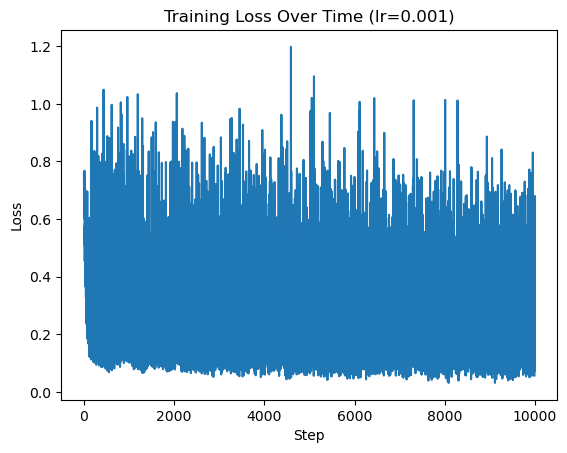

In [11]:
# Plot the loss curve and save (optional)

import matplotlib.pyplot as plt
import os

plt.plot(loss_vec)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Over Time (lr=" + str(lr) + ")")
# Make sure the folder exists
if store_image:
    folder = f'figures/m_{m}_n_{n}_s_{seed}'
    os.makedirs(folder, exist_ok=True)
    plt.savefig(f"{folder}/loss.pdf") 
plt.show()

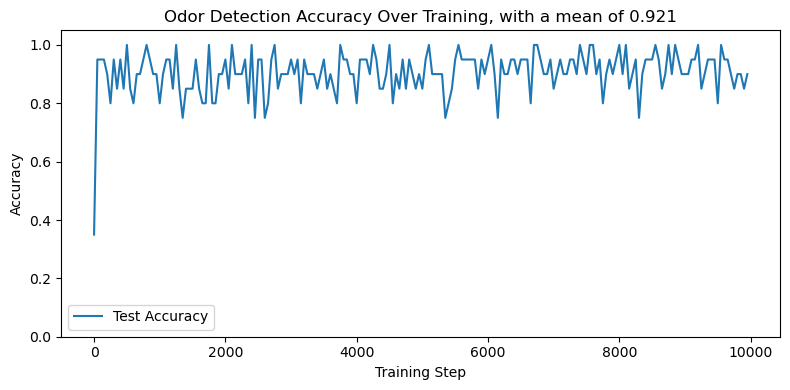

In [12]:
# Plot the test accuracy curve

import matplotlib.pyplot as plt

# mean_accuracy = torch.mean()

plt.figure(figsize=(8, 4))
plt.plot(torch.arange(0, steps, 50), accuracy_vec, label='Test Accuracy')
plt.xlabel("Training Step")
plt.ylabel("Accuracy")
plt.title(f"Odor Detection Accuracy Over Training, with a mean of {mean_accuracy:.3f}")
plt.ylim(0, 1.05)
# plt.grid(True)
plt.legend()
plt.tight_layout()
if store_image:
    plt.savefig(f"{folder}/accuracy.pdf")

plt.show()

# plot the weight matrices

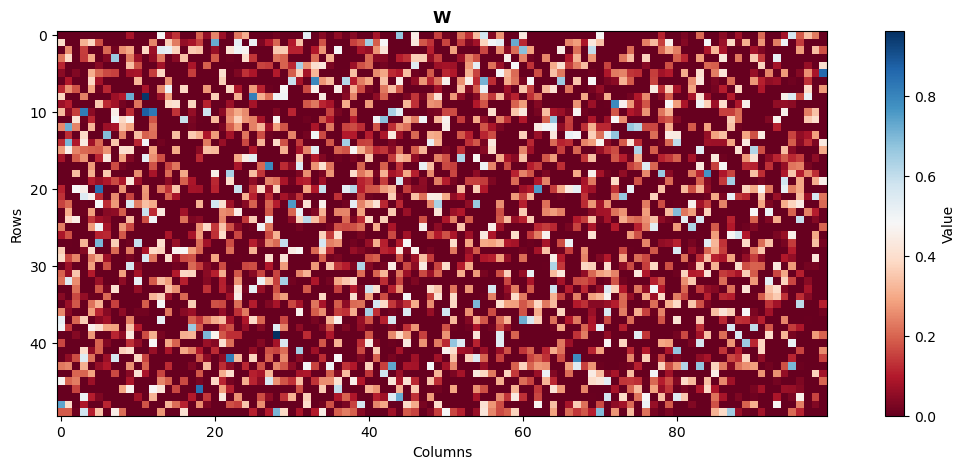

In [24]:
import torch
import matplotlib.pyplot as plt
W = enose_network.W.cpu().numpy()
# Plot using imshow
plt.figure(figsize=(15, 5))
plt.imshow(W, cmap='RdBu', interpolation='nearest')
plt.colorbar(label='Value')
plt.title(r'$\bf W$')
plt.xlabel('Columns')
plt.ylabel('Rows')
if store_image:
    plt.savefig(f"{folder}/W.pdf", bbox_inches='tight')
plt.show()

## plot the matrices

In [14]:
enose_network.fc1.bias

Parameter containing:
tensor([0.2623], device='mps:0', requires_grad=True)

1
-0.07754658


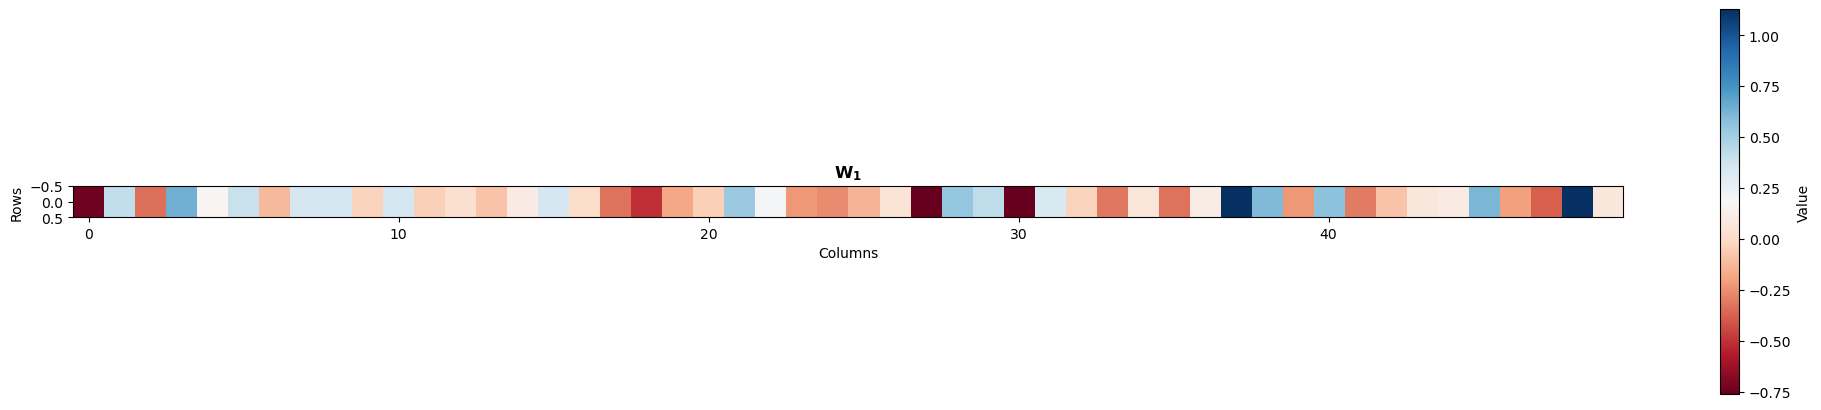

In [26]:
import torch
import matplotlib.pyplot as plt

W1 = enose_network.fc1.weight.detach().cpu().numpy()
b1 = enose_network.fc1.bias.detach().cpu().numpy()
print(b1.size)

W_h = W1 @ W
x1_hat_dagger = -b1[0]/W_h[0,0].item()
print(x1_hat_dagger)

# Plot using imshow
plt.figure(figsize=(25, 5))
plt.imshow(W1, cmap='RdBu', interpolation='nearest')
plt.colorbar(label='Value')
plt.title(r'$\bf W_1$')
plt.xlabel('Columns')
plt.ylabel('Rows')
if store_image:
    plt.savefig(f"{folder}/W1.pdf", bbox_inches='tight')
plt.show()

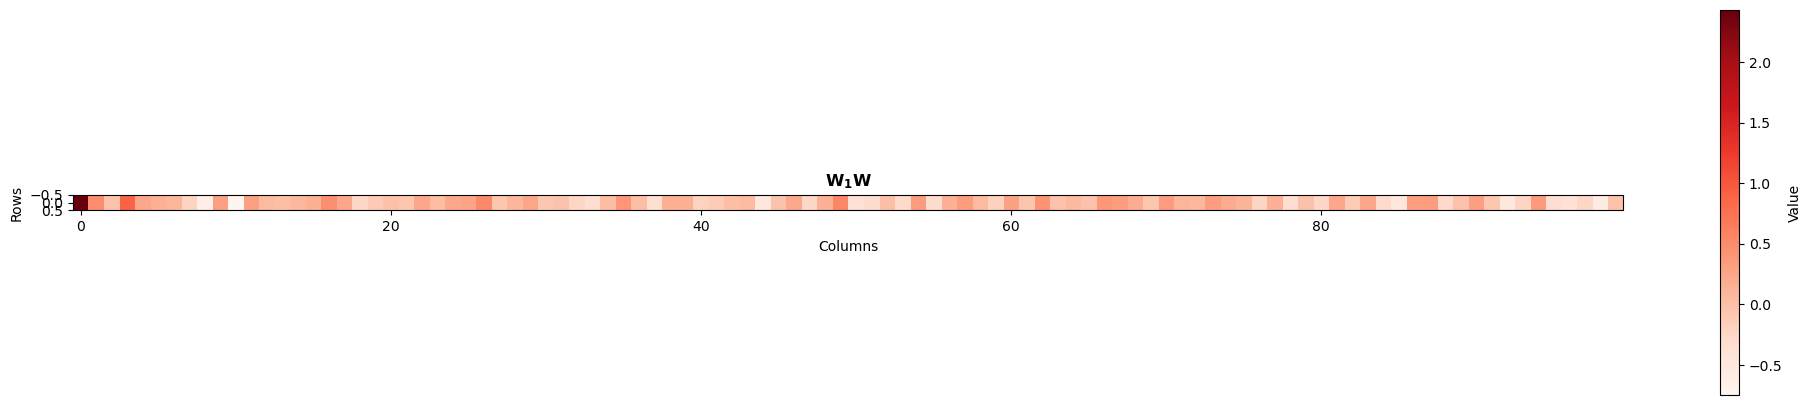

[ 2.431812    0.4894402  -0.04101301  0.8912103   0.24340826  0.14963025
  0.0959745  -0.21581413 -0.62321734  0.30213422 -0.7474677   0.30202395
  0.04956629  0.00305859  0.07322096  0.15396257  0.47274527  0.24164933
 -0.27207977 -0.11530715 -0.02224926 -0.06759775  0.24547315  0.03344011
  0.22911154  0.26970762  0.52472585 -0.06811673  0.09370577  0.2474431
 -0.08663395 -0.05116399 -0.24839495 -0.3279881   0.02761605  0.40263915
  0.01547183 -0.3504087   0.15783694  0.15899383 -0.21279739 -0.12783459
  0.0095769   0.05623213 -0.49899504 -0.04514564  0.23271048 -0.2564105
  0.1385634   0.5516785  -0.37829283 -0.3245963  -0.01167815 -0.28126723
  0.35129952 -0.32184342  0.14926033  0.3383906   0.04950494 -0.19996594
  0.2890485  -0.05541285  0.43091518 -0.03827317  0.06759224 -0.03095557
  0.3866499   0.33378714  0.19265439 -0.06853639  0.34984967  0.10796249
  0.08311778  0.339182    0.19762278  0.12093483 -0.23208645  0.13952398
 -0.33425823 -0.02624338 -0.25904047  0.23462425 -0.1

In [25]:
import torch
import matplotlib.pyplot as plt

# Plot using imshow
plt.figure(figsize=(25, 5))
plt.imshow(W_h , cmap='Reds', interpolation='nearest')
plt.colorbar(label='Value')
plt.title(r'$\bf W_1 W$')
plt.xlabel('Columns')
plt.ylabel('Rows')
if store_image:
    plt.savefig(f"{folder}/W_h.pdf")
# plt.savefig("figures/W_h.pdf")
plt.show()
plt.close()

# to verify that the first element dominates
print(W_h[0]) 

# plot the simplified 1-D curve, since the first element dominates

In [17]:
x_hat = threshold
print(x_hat)
print(x1_hat_dagger)

0.1
-0.10787824


/var/folders/2w/xwcnb67d2wq2rf_47cyk6vpr0000gn/T/ipykernel_10511/3394132130.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y = torch.sigmoid( W_h[0][0]*x + b1 )


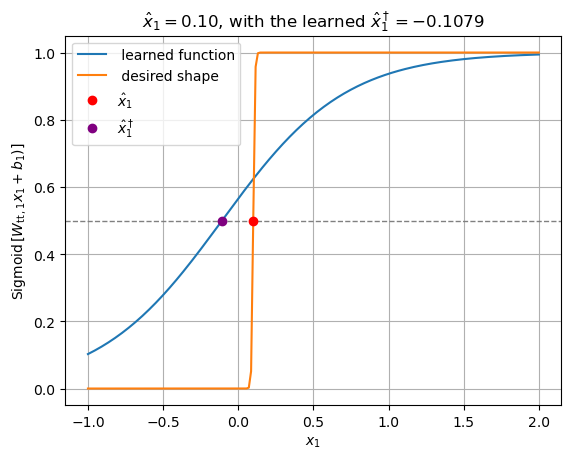

In [18]:
# x = torch.linspace(0, 1, 200)
x = torch.linspace(-1, 2, 200)

y = torch.sigmoid( W_h[0][0]*x + b1 )
y_2 = torch.sigmoid( 200*(x - x_hat) )
plt.plot(x, y, label =' learned function')
plt.plot(x, y_2, label = ' desired shape')
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
plt.plot(x_hat, 0.5, 'o', color='red', label=r'$\hat{x}_1$')
plt.plot(x1_hat_dagger, 0.5, 'o', color='purple', label=r'$\hat{x}_1^\dagger$')


plt.title(fr'$\hat{{x}}_1 = {x_hat:.2f} $, with the learned $\hat{{x}}_1^\dagger = {x1_hat_dagger:.4f} $')
plt.xlabel(r'$x_1$')
plt.ylabel(r'$\operatorname{Sigmoid}\left[ W_{\operatorname{tt},1} x_1 + b_1 ) \right]$')
plt.legend()
plt.grid(True)
if store_image:
    plt.savefig(f"{folder}/pickup_first_dim.pdf", bbox_inches='tight')
plt.show()

# correlated perturbation of W matrix*

original W matrix
tensor([[-0.2158, -0.1061, -0.0925,  ...,  0.1683,  0.1155, -0.1292],
        [ 0.1959, -0.1151, -0.1312,  ..., -0.2613, -0.4125, -0.0802],
        [-0.0765,  0.1266, -0.1248,  ..., -0.0083,  0.1667,  0.0880],
        ...,
        [-0.0316, -0.0210, -0.1246,  ..., -0.2514,  0.0790, -0.1586],
        [ 0.3686,  0.1974, -0.1578,  ..., -0.2046,  0.0182, -0.0290],
        [ 0.0935,  0.0925,  0.0074,  ..., -0.1880, -0.1794, -0.2198]],
       device='mps:0')
transformed W matrix
tensor([[-0.2136, -0.1050, -0.0916,  ...,  0.1700,  0.1166, -0.1279],
        [ 0.1978, -0.1139, -0.1299,  ..., -0.2587, -0.4084, -0.0794],
        [-0.0758,  0.1279, -0.1236,  ..., -0.0082,  0.1684,  0.0889],
        ...,
        [-0.0313, -0.0208, -0.1233,  ..., -0.2488,  0.0798, -0.1570],
        [ 0.3722,  0.1993, -0.1563,  ..., -0.2026,  0.0184, -0.0287],
        [ 0.0945,  0.0934,  0.0075,  ..., -0.1861, -0.1776, -0.2176]],
       device='mps:0')
original W matrix
tensor([[-0.2158, -0.1061, -0

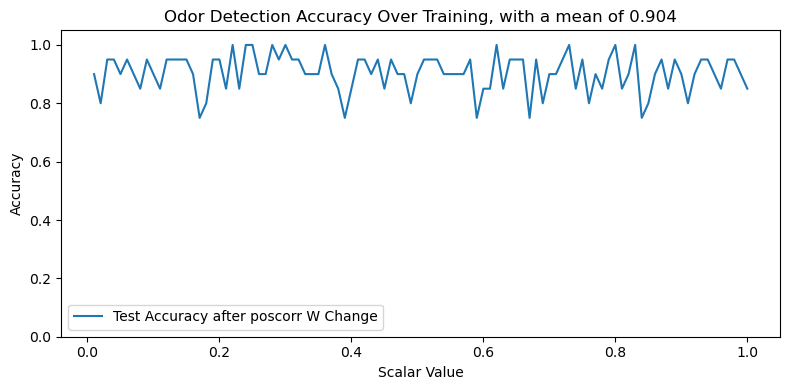

In [19]:
scalars = np.arange(0.1,10.1,0.1).tolist()
corr_scalars = np.arange(0.01, 1.01, 0.01).tolist()
poscorr_perturb_accuracies = torch.zeros(len(scalars))
randn_perturb_accuracies = torch.zeros(len(scalars))
scalarmult_perturb_accuracies = torch.zeros(len(scalars))
original_W = enose_network.W.clone() # original odorant-to-measurement matrix W

# # iterate over magnitude of scalar multiplication 
# for idx,scalar in enumerate(scalars):

#     # change W matrix
#     enose_network.W = (original_W * scalar).to(device)

#     # evaluate test accuracy of NN
#     scalarmult_perturb_accuracies[idx] = network.eval_model_accuracy(enose_network, test_conc, test_labels, num_data, num_training, test_batch_size, device)


# iterate over magnitude of positively-correlated noise 
for idx,percent in enumerate(corr_scalars):

    # change W matrix in the positive direction
    print("original W matrix")
    print(original_W)

    enose_network.W = (torch.abs(original_W) * percent + original_W).to(device)

    print("transformed W matrix")
    print(enose_network.W)

    # evaluate test accuracy of NN
    poscorr_perturb_accuracies[idx] = network.eval_model_accuracy(enose_network, test_conc, test_labels, num_data, num_training, test_batch_size, device)


# # iterate the same number of times but for random re-initializations
# for idx,scalar in enumerate(scalars):

#     # change W matrix in the positive direction
#     enose_network.W = torch.randn(enose_network.W.shape[0], enose_network.W.shape[1]).to(device)

#     # evaluate test accuracy of NN
#     randn_perturb_accuracies[idx] = network.eval_model_accuracy(enose_network, test_conc, test_labels, num_data, num_training, test_batch_size, device)


scalarmult_mean_accuracy = torch.mean(scalarmult_perturb_accuracies)
poscorr_mean_accuracy = torch.mean(poscorr_perturb_accuracies)
randn_mean_accuracy = torch.mean(randn_perturb_accuracies)


# plots to view
for change_type in range(0,1):
    plt.figure(figsize=(8, 4))
    change_type_str = "poscorr"
    plot_mean_accuracy = 0
    plot_accuracy_vec = poscorr_perturb_accuracies
    plot_scalars = corr_scalars
    plot_mean_accuracy = poscorr_mean_accuracy

    # if change_type == 0:
    #     change_type_str = "randn"
    #     plot_mean_accuracy = randn_mean_accuracy
    #     plot_accuracy_vec = randn_perturb_accuracies
    # elif change_type == 1:
    #     change_type_str = "scalarmult"
    #     plot_mean_accuracy = scalarmult_mean_accuracy
    #     plot_accuracy_vec = scalarmult_perturb_accuracies
    # elif change_type == 2:
    #     change_type_str = "poscorr"
    #     plot_mean_accuracy = poscorr_mean_accuracy
    #     plot_accuracy_vec = poscorr_perturb_accuracies
    #     plot_scalars = corr_scalars

    plt.plot(plot_scalars, plot_accuracy_vec, label='Test Accuracy after ' + change_type_str + ' W Change')
    plt.xlabel("Scalar Value")
    plt.ylabel("Accuracy")
    plt.title(f"Odor Detection Accuracy Over Training, with a mean of {plot_mean_accuracy:.3f}")
    plt.ylim(0, 1.05)
    # plt.grid(True)
    plt.legend()
    plt.tight_layout()
    if store_image:
        fig_folder = '/Users/ericxu/Documents/Github/Murthy_NeuralNetwork/2_sorted_out_variant_one_layer/eric_weight_perturb_figures' 
        plt.savefig(f"{fig_folder}/" + change_type_str + "_perturb_accuracy.pdf")

    plt.show()



# ask about the code below since i'm not too sure what this means

## verify that the analytical full expression is correct; compare the full expression versus the simplified 1-D expression

In [20]:
# the test dataset
test_idx = torch.randint(0, num_data - num_training, (test_batch_size,))
x_test = test_conc[:, test_idx]
y_test = test_labels[test_idx].view(-1, 1).float()

In [21]:
## ===== to check the analytical expression matches with the network expression =====

W_h_tensor = torch.tensor(W_h, dtype=torch.float32, device=x_test.device)
bias_final = torch.tensor(b1, dtype=torch.float32, device=x_test.device)

# the network expression
with torch.no_grad():
    enose_network.eval()
    pred = enose_network(x_test)
    predicted_labels = (pred > 0.5).float()
    accuracy = (predicted_labels == y_test).float().mean().item()
    # accuracy_vec[ steps // test_interval] = accuracy
    print(f"Test Accuracy = {accuracy:.4f}")

print(pred.mT)

# the analytical expression
out1 = torch.sigmoid(W_h_tensor @ x_test + bias_final)  # shape: [output_dim, num_samples]
out1 = out1[0]
print(out1)

Test Accuracy = 0.9500
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1.]], device='mps:0')
tensor([0.8482, 0.8919, 0.9628, 0.9370, 0.7385, 0.9617, 0.9126, 0.9281, 0.8141,
        0.9706, 0.8651, 0.9763, 0.9913, 0.9782, 0.8862, 0.6221, 0.9550, 0.9461,
        0.8134, 0.8971], device='mps:0')


In [22]:
out2 = torch.sigmoid(W_h_tensor[0][0] * x_test[0, :] + bias_final)  # shape: [num_samples]
out3 = torch.sigmoid(W_h_tensor[0][0] * (x_test[0, :] - x1_hat_dagger) )  # shape: [num_samples]
out4 = torch.sigmoid(W_h_tensor[0][0] * (x_test[0, :] - x_hat) )  # shape: [num_samples]

accr_1 = ((out1 > 0.5).float().T == y_test.squeeze()).float().mean().item()
accr_2 = ((out2 > 0.5).float().T == y_test.squeeze()).float().mean().item()

/var/folders/2w/xwcnb67d2wq2rf_47cyk6vpr0000gn/T/ipykernel_10511/4066574986.py:5: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1729646995093/work/aten/src/ATen/native/TensorShape.cpp:3687.)
  accr_1 = ((out1 > 0.5).float().T == y_test.squeeze()).float().mean().item()


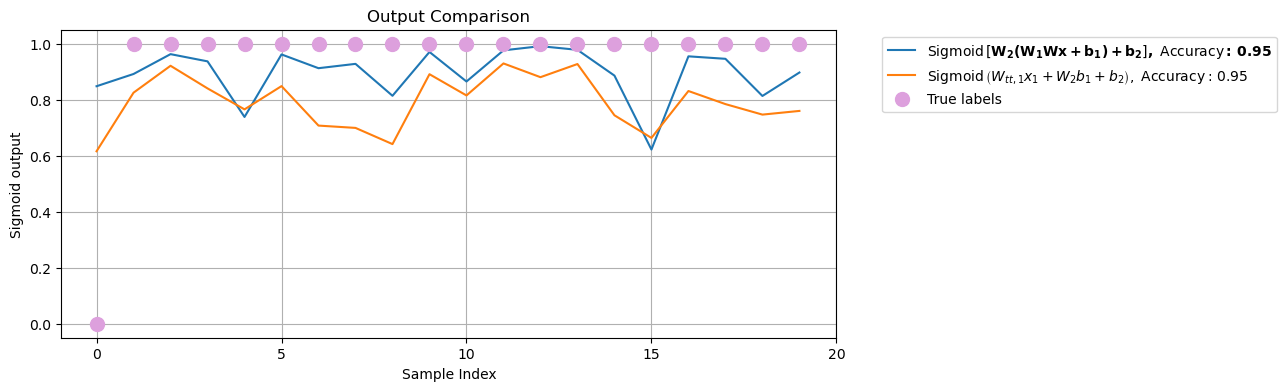

In [23]:
import torch
import matplotlib.pyplot as plt

# Plot comparison
plt.figure(figsize=(10, 4))
plt.plot(out1.cpu(), label=fr'$\operatorname{{Sigmoid}}\left[\bf W_2 (W_1 Wx +b_1)+b_2 \right],\ \operatorname{{Accuracy: }} {accr_1:.2f} $')
plt.plot(out2.cpu(), label=fr'$\operatorname{{Sigmoid}}\left(W_{{tt,1}} x_1 + W_2b_1+b_2 \right),\ \operatorname{{Accuracy: }} {accr_2:.2f} $')
# plt.plot(out3.cpu(), label=fr'$\operatorname{{Sigmoid}}\left[\bf W_2 (W_1 Wx +b_1)+b_2 \right],\ \operatorname{{Accuracy: }} {accr_1:.2f} $')
# plt.plot(out4.cpu(), label=fr'$\operatorname{{Sigmoid}}\left(W_{{tt,1}} x_1 + W_2b_1+b_2 \right),\ \operatorname{{Accuracy: }} {accr_2:.2f} $')
# plt.plot(log_out2.cpu(), label=r'$\operatorname{Sigmoid}$', linestyle='--')
plt.plot(y_test.cpu(), label = 'True labels', linestyle='none', marker='.', markersize = 20, color='plum')
plt.title("Output Comparison")
plt.xlabel("Sample Index")
plt.xticks(ticks=range(0, len(y_test)+1,5), labels=range(0, len(y_test)+1,5))
plt.ylabel("Sigmoid output")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
if store_image:
    plt.savefig(f"{folder}/Output_Comparison.pdf", bbox_inches='tight')
plt.show()